In [167]:
import pandas as pd

df = pd.read_csv('day.csv')


In [250]:
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

Más informacióm del dataset

El objetivo es predecir cuantas vicicletas se van a rentar

https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset


Quita las variables de casual, registered, instant, fecha, mes, año de tu entrenamiento

Hay varias categoricas, cuales son? coviertelas e one hot encoding

Crea variables dummy

In [169]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [170]:
df.season.unique()

array([1, 2, 3, 4])

In [171]:
df[['casual', 'cnt']].corr()

,casual,cnt
casual,1.000000,0.672804
cnt,0.672804,1.000000


In [172]:
df = df.drop(['casual', 'registered', 'instant', 'dteday'], axis=1)


categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,yr_1,mnth_2,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,0.344167,0.363625,0.805833,0.160446,985,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0.363478,0.353739,0.696087,0.248539,801,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.196364,0.189405,0.437273,0.248309,1349,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,0.200000,0.212122,0.590435,0.160296,1562,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,0.226957,0.229270,0.436957,0.186900,1600,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


# **analisis bivariado variables numericas:**

In [173]:
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed']

**temp**

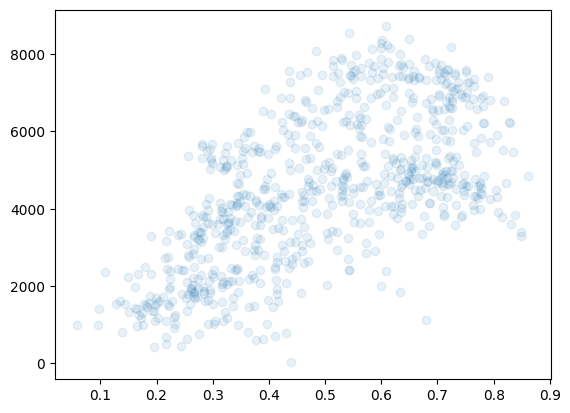

In [174]:
plt.scatter(df.temp, df.cnt, alpha = 0.1)


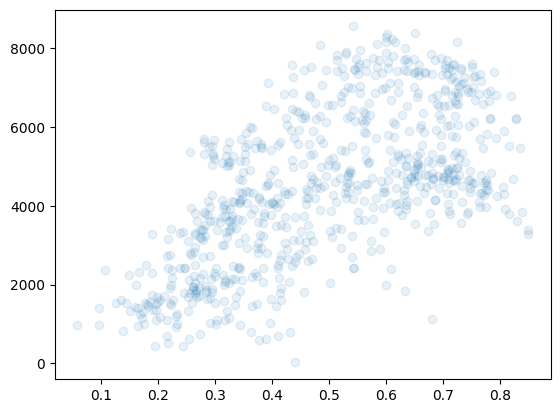

In [175]:
df_temp = df[(df.cnt != df.cnt.max()) &
    (df.temp != df.temp.max())]
plt.scatter(df_temp.temp, df_temp.cnt, alpha = 0.1)

In [176]:
df_temp['temp_bin'] = pd.qcut(df_temp['temp'], q=10, labels=False) + 1

<ipython-input-176-67aef8067e83>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['temp_bin'] = pd.qcut(df_temp['temp'], q=10, labels=False) + 1


In [177]:
grouped_temp = df_temp.groupby('temp_bin').mean()

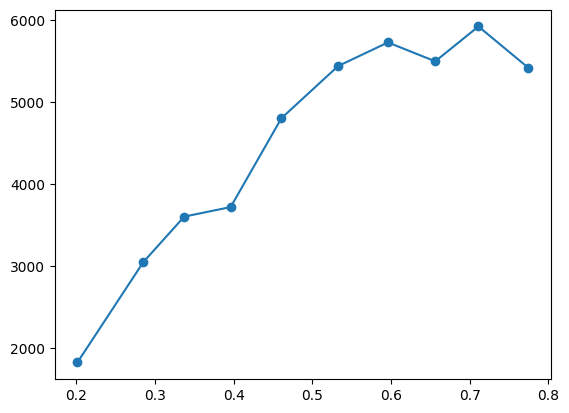

In [178]:
plt.plot(grouped_temp.temp.values, grouped_temp.cnt.values, marker = "o")

En esta gráfica a pesar de no ser totalmente lineal, podemos decir que la variable de temperatura es una variable que si tiene una fuerte influencia en si se renta una bicicleta o no.

In [179]:
model_temp = linear_model.LinearRegression()
X_temp = df_temp[['temp']]
y_temp = df_temp[['cnt']]
model_temp.fit(X_temp,y_temp)

LinearRegression()

In [180]:
model_temp.coef_

array([[6656.18878263]])

In [181]:
model_temp.intercept_

array([1205.1148313])

$$cnt = 6656.18 + 1205.11 * temp$$






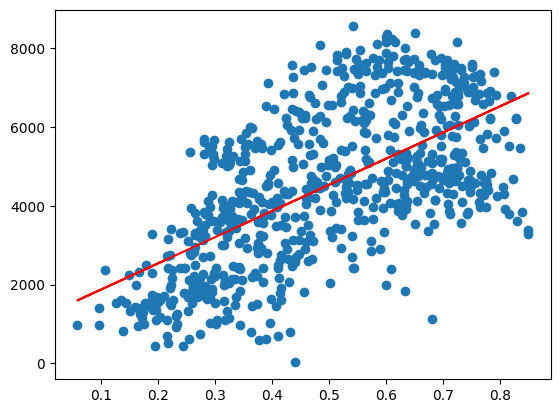

In [182]:
predicciones_temp = model_temp.predict(X_temp)
plt.scatter(X_temp, y_temp)
plt.plot(X_temp, predicciones_temp, c = 'red')

In [183]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = y_temp,
                   y_pred = predicciones_temp)

2255793.4029542296

In [184]:
r2_score(y_true = y_temp,
        y_pred = predicciones_temp)

0.3957858812338333

**atemp**

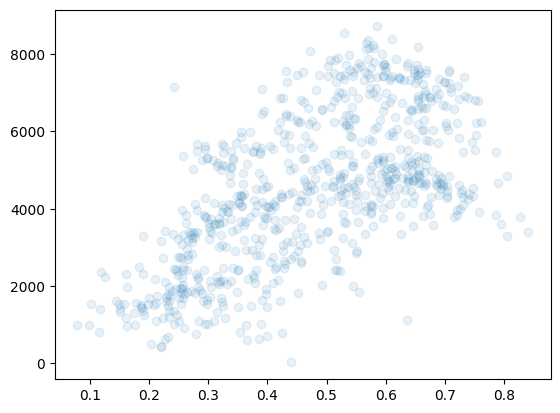

In [185]:
plt.scatter(df.atemp, df.cnt, alpha = 0.1)


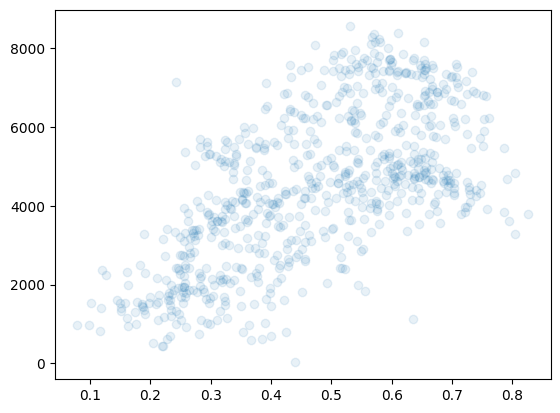

In [186]:
df_atemp = df[(df.cnt != df.cnt.max()) &
    (df.atemp != df.atemp.max())]
plt.scatter(df_atemp.atemp, df_atemp.cnt, alpha = 0.1)


In [187]:
df_atemp['atemp_bin'] = pd.qcut(df_atemp['atemp'], q=10, labels=False) + 1

<ipython-input-187-f33643412686>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_atemp['atemp_bin'] = pd.qcut(df_atemp['atemp'], q=10, labels=False) + 1


In [188]:
grouped_atemp = df_atemp.groupby('atemp_bin').mean()

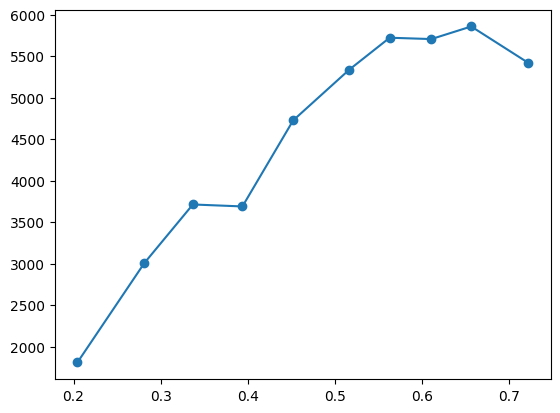

In [189]:
plt.plot(grouped_atemp.atemp.values, grouped_atemp.cnt.values, marker = "o")

In [190]:
model_atemp = linear_model.LinearRegression()
X_atemp = df_atemp[['temp']]
y_atemp = df_atemp[['cnt']]
model_atemp.fit(X_atemp,y_atemp)

LinearRegression()

In [191]:
model_atemp.coef_

array([[6674.86954801]])

In [192]:
model_atemp.intercept_

array([1197.74399719])

$$ cnt = 6674.86 + 1197.74 * atemp$$

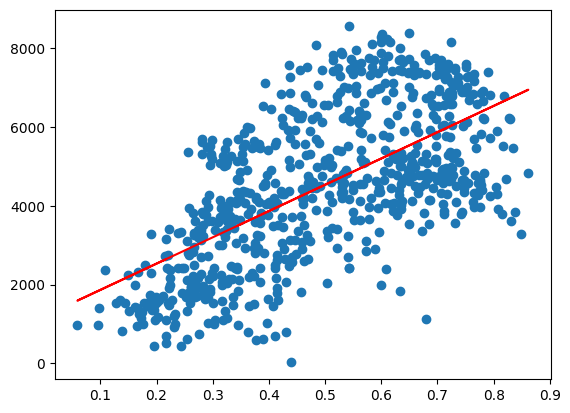

In [193]:
predicciones_atemp = model_atemp.predict(X_atemp)
plt.scatter(X_atemp, y_atemp)
plt.plot(X_atemp, predicciones_atemp, c = 'red')

In [194]:
mean_squared_error(y_true = y_atemp,
                   y_pred = predicciones_atemp)

2245363.36392479

In [195]:
r2_score(y_true = y_atemp,
        y_pred = predicciones_atemp)

0.39833184403942157

**hum**

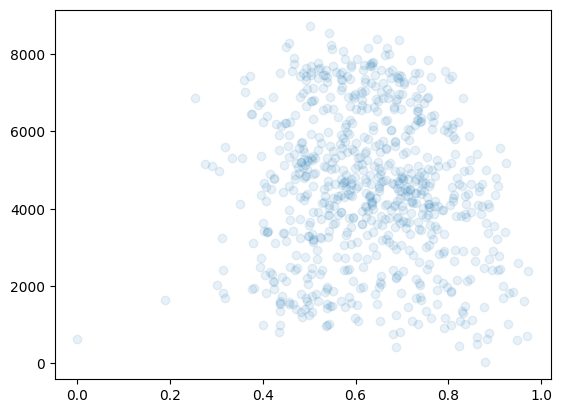

In [196]:
plt.scatter(df.hum, df.cnt, alpha = 0.1)


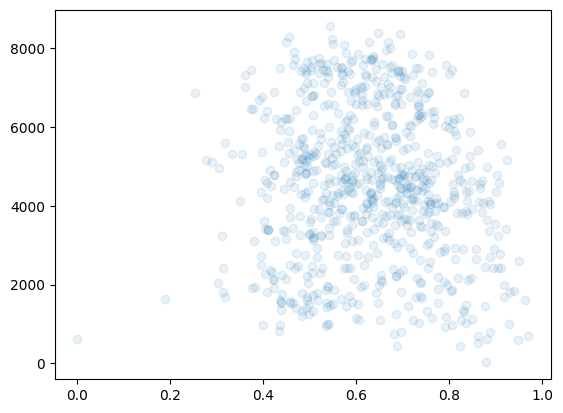

In [197]:
df_hum = df[(df.cnt != df.cnt.max()) &
    (df.hum != df.hum.max())]
plt.scatter(df_hum.hum, df_hum.cnt, alpha = 0.1)


In [198]:
df_hum['hum_bin'] = pd.qcut(df_hum['hum'], q=10, labels=False) + 1

<ipython-input-198-0775c63157a5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hum['hum_bin'] = pd.qcut(df_hum['hum'], q=10, labels=False) + 1


In [199]:
grouped_hum = df_hum.groupby('hum_bin').mean()

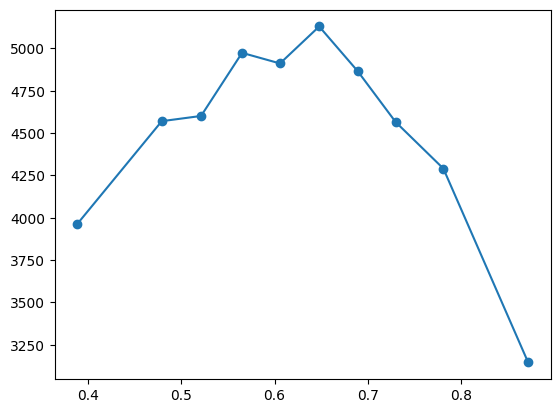

In [200]:
plt.plot(grouped_hum.hum.values, grouped_hum.cnt.values, marker = "o")

la variable hum parece no ser un muy buen indicador para utilizar en el modelo. Ya que tiene una pendiente negativa que nos dice que en cuento más suba esta variable no sube la variable cnt

In [201]:
model_hum = linear_model.LinearRegression()
X_hum = df_hum[['hum']]
y_hum = df_hum[['cnt']]
model_hum.fit(X_hum,y_hum)

LinearRegression()

In [202]:
model_hum.coef_

array([[-1295.94817698]])

In [203]:
model_hum.intercept_

array([5314.79771667])

$$ cnt = -12295.94 + 5314 * hum$$

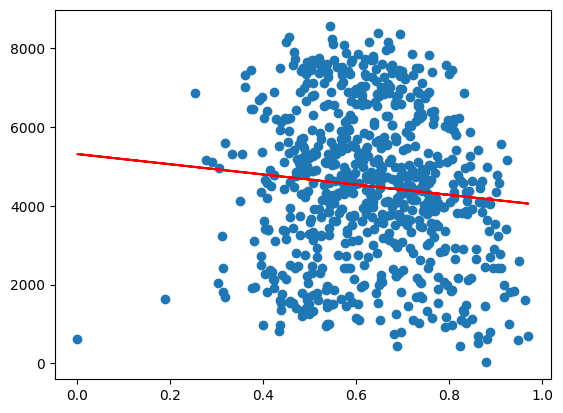

In [204]:
predicciones_hum = model_hum.predict(X_hum)
plt.scatter(X_hum, y_hum)
plt.plot(X_hum, predicciones_hum, c = 'red')

In [205]:
mean_squared_error(y_true = y_hum,
                   y_pred = predicciones_hum)

3693709.199500426

In [206]:
r2_score(y_true = y_hum,
        y_pred = predicciones_hum)

0.009069401812319966

Aquí tambien podemos saber que el usar esta variable hum no es necesario porque en R^2 es mucho menor

**windspeed**

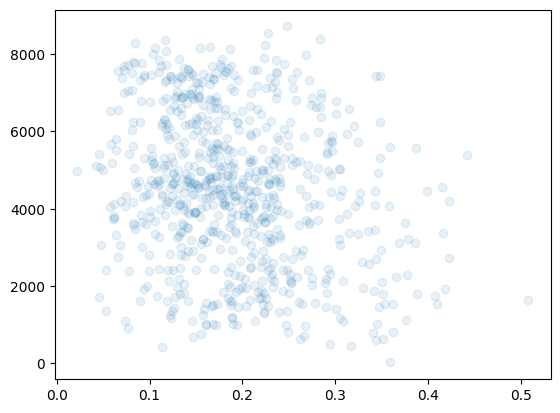

In [207]:
plt.scatter(df.windspeed, df.cnt, alpha = 0.1)


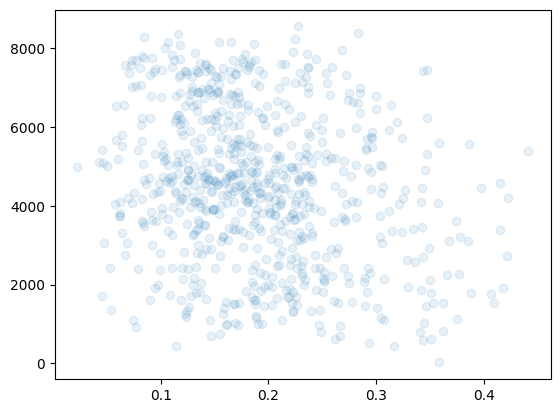

In [208]:
df_windspeed = df[(df.cnt != df.cnt.max()) &
    (df.windspeed != df.windspeed.max())]
plt.scatter(df_windspeed.windspeed, df_windspeed.cnt, alpha = 0.1)


In [209]:
df_windspeed['windspeed_bin'] = pd.qcut(df_windspeed['windspeed'], q=10, labels=False) + 1

<ipython-input-209-e4ea5ce33ddb>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_windspeed['windspeed_bin'] = pd.qcut(df_windspeed['windspeed'], q=10, labels=False) + 1


In [210]:
grouped_windspeed = df_windspeed.groupby('windspeed_bin').mean()

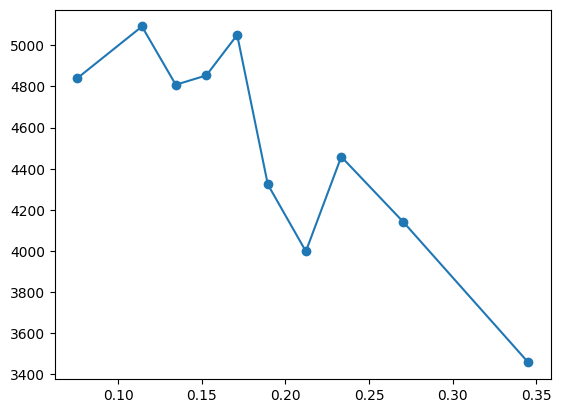

In [211]:
plt.plot(grouped_windspeed.windspeed.values, grouped_windspeed.cnt.values, marker = "o")

también con pendiente negativa, es decir entre más velocidad del viento menor renta de bicicletas.

In [212]:
model_windspeed = linear_model.LinearRegression()
X_windspeed = df_windspeed[['windspeed']]
y_windspeed = df_windspeed[['cnt']]
model_windspeed.fit(X_windspeed,y_windspeed)

LinearRegression()

In [213]:
model_windspeed.coef_

array([[-5849.02062222]])

In [214]:
model_windspeed.intercept_

array([5613.66724313])

$$ cnt = -5849 + 5613 * windspeed$$

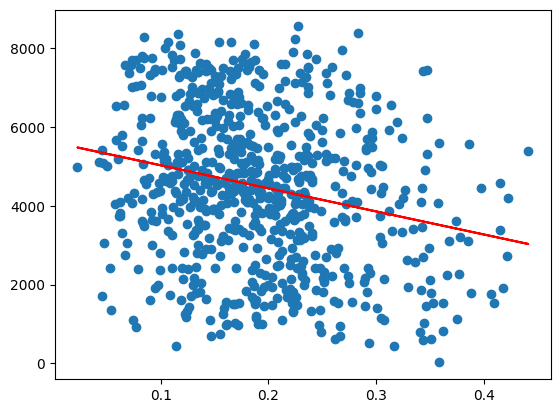

In [215]:
predicciones_windspeed = model_windspeed.predict(X_windspeed)
plt.scatter(X_windspeed, y_windspeed)
plt.plot(X_windspeed, predicciones_windspeed, c = 'red')

In [216]:
mean_squared_error(y_true = y_windspeed,
                   y_pred = predicciones_windspeed)

3521456.2053620205

In [217]:
r2_score(y_true = y_windspeed,
        y_pred = predicciones_windspeed)

0.05396454274317708

menor mean squared error que variables temp y atemp

# Regresión Lineal Multiple

In [218]:
X_multiple = df[['cnt', 'temp', 'atemp']]
y = df[['cnt']]
model_multiple = linear_model.LinearRegression()
model_multiple.fit(X_multiple, y)
predicciones_multiple = model_multiple.predict(X_multiple)
r2_score(y_true = y, y_pred = predicciones_multiple)

1.0

In [219]:
df.isna().sum()

,0
temp,0
atemp,0
hum,0
windspeed,0
cnt,0
season_2,0
season_3,0
season_4,0
yr_1,0
mnth_2,0


In [220]:
X = df[['temp', 'atemp']]
model_todo = linear_model.LinearRegression()
model_todo.fit(X,y)
predicciones_todo = model_todo.predict(X)
r2_score(y_true=y, y_pred = predicciones_todo)

0.398411681353635

**El R^2 de la regresion lineal es 0.4**

In [221]:
coeficientes = pd.DataFrame({
    "names": X.keys(),
    "coeficientes": model_todo.coef_[0]
})
coeficientes

,names,coeficientes
0,temp,1066.211977
1,atemp,6314.118269


In [222]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': predicciones_todo[:,0],
    'real': y['cnt']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

grouped_calibracion

,predicciones,real
bins,,
1,2494.940726,1753.108108
2,3070.956687,3092.780822
3,3471.281804,3679.410959
4,3895.451480,3737.273973
5,4331.830754,4772.095890
6,4818.835411,5353.452055
7,5177.520054,5735.069444
8,5537.632824,5668.891892
9,5888.210442,5878.561644


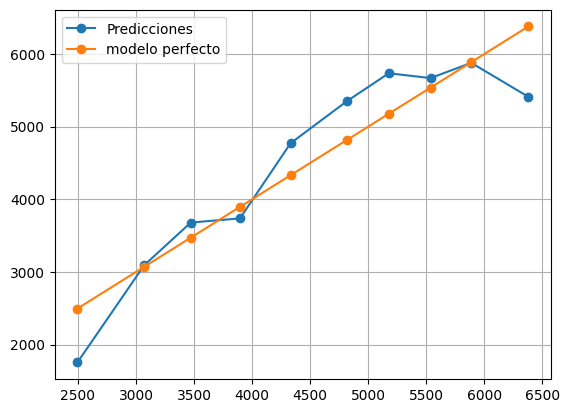

In [223]:
import matplotlib.pyplot as plt
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()

Las variables que mejor pueden ayudar a predecir cuantas bicicletas se van a rentar son las de temp y atemp.

# Regresión Polinomial


In [235]:
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

target = 'cnt'
df = pd.get_dummies(df)

In [236]:
# Bivariado de temp
df['temp_bin'] = pd.qcut(df['temp'], q=10, labels=False) + 1
bivariado_temp = df.groupby('temp_bin').mean()

In [237]:
# Regresion lineal simple temp
X = df[['temp']]
y = df[target]
model = linear_model.LinearRegression().fit(X, y)
df['predicciones_simple'] = model.predict(X)

**Regresión polinomial grado 2**

In [238]:
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)
df['predicciones_poly2'] = model.predict(X_poly)


In [239]:
r2_score(y_pred=predicciones_poly2, y_true=y)

0.4531790254908288

**El R^2 de la regresion polinomial de grado 2 es 0.45**  (mejor que la regresión lineal)

**Regresion polinomial grado 3**

In [240]:
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)
df['predicciones_poly3'] = model.predict(X_poly)


In [241]:
r2_score(y_pred=predicciones_poly3, y_true=y)

0.46265262824587394

**El R^2 de la regresion polinomial de grado 3 es 0.46** La mejor regresión ya que el R^2 e el mayor.

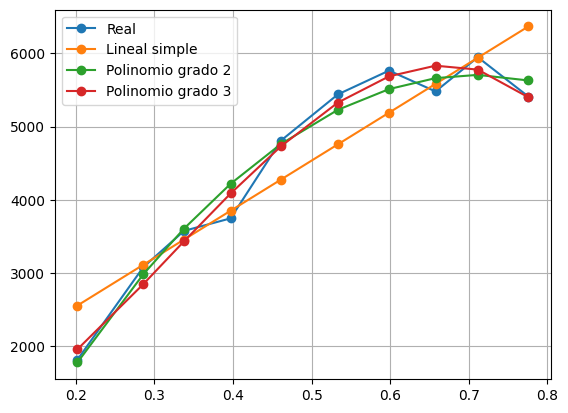

In [242]:
# Bivariado vs regresion lineal
plt.plot(bivariado_temp.temp.values,
        bivariado_temp.cnt.values, marker="o", label="Real")

plt.plot(bivariado_temp.temp.values,
        bivariado_temp.predicciones_simple.values, marker="o", label="Lineal simple")

plt.plot(bivariado_temp.temp.values,
        bivariado_temp.predicciones_poly2.values, marker="o", label="Polinomio grado 2")


plt.plot(bivariado_temp.temp.values,
        bivariado_temp.predicciones_poly3.values, marker="o", label="Polinomio grado 3")


plt.legend()
plt.grid()

En esta gráfica podemos verificar que en efecto la regresión polinomial de grado 3 se acerca más a la realidad


# Calibración

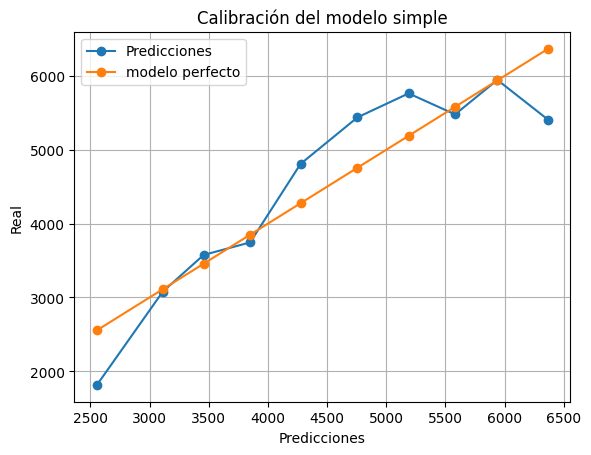

In [247]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': df['predicciones_simple'],
    'real': df['cnt']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo simple")
plt.show()


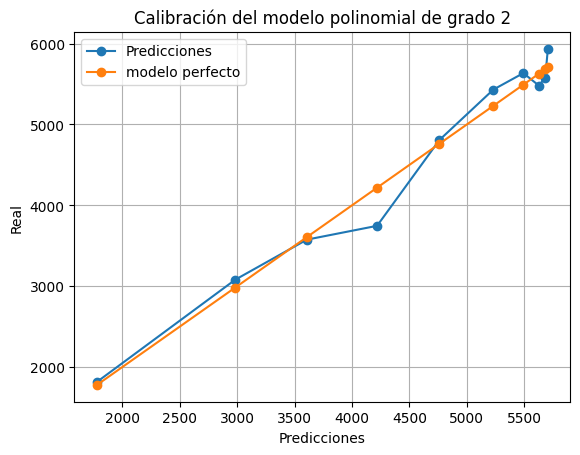

In [245]:

# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': df['predicciones_poly2'],
    'real': df['cnt']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo polinomial de grado 2")
plt.show()


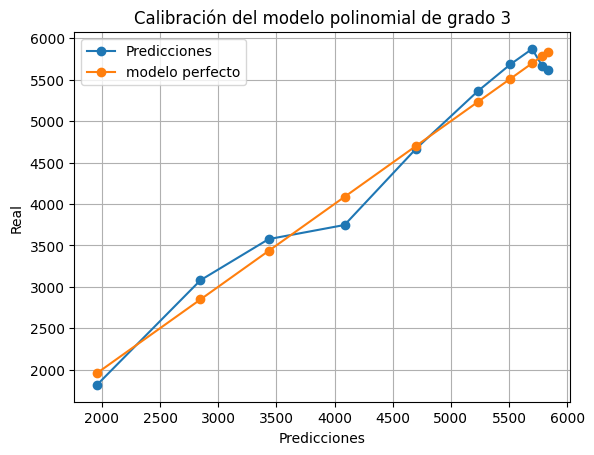

In [246]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': df['predicciones_poly3'],
    'real': df['cnt']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo polinomial de grado 3")
plt.show()


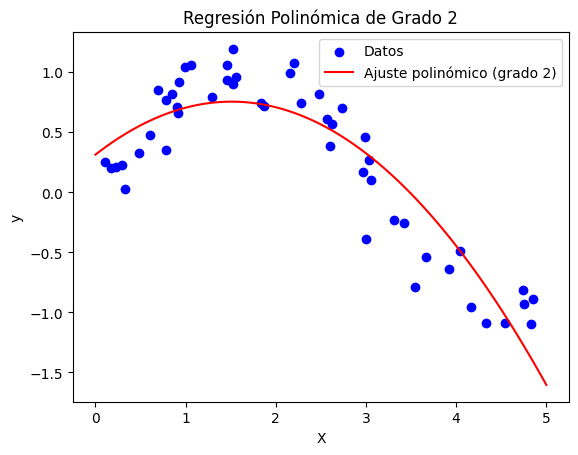

In [252]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generar datos simulados
np.random.seed(42)
X = np.sort(5 * np.random.rand(50, 1), axis=0)  # Valores entre 0 y 5
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])  # Seno con ruido

# Crear la transformación polinómica de grado 2
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_poly, y)

# Predecir valores
X_fit = np.linspace(0, 5, 100).reshape(-1, 1)
X_fit_poly = poly_features.transform(X_fit)  # Transformar X_fit a características polinómicas
y_fit = model.predict(X_fit_poly)

# Graficar los resultados
plt.scatter(X, y, color="blue", label="Datos")
plt.plot(X_fit, y_fit, color="red", label="Ajuste polinómico (grado 2)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Polinómica de Grado 2")
plt.show()

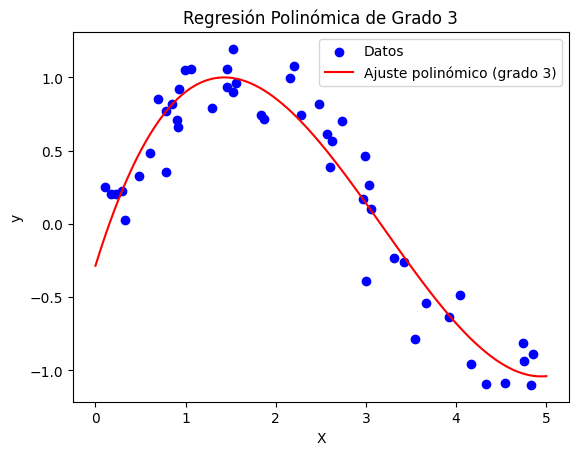

In [253]:
# Generar datos simulados
np.random.seed(42)
X = np.sort(5 * np.random.rand(50, 1), axis=0)  # Valores entre 0 y 5
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])  # Seno con ruido

# Crear la transformación polinómica de grado 3
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_poly, y)

# Predecir valores
X_fit = np.linspace(0, 5, 100).reshape(-1, 1)
X_fit_poly = poly_features.transform(X_fit)  # Transformar X_fit a características polinómicas
y_fit = model.predict(X_fit_poly)

# Graficar los resultados
plt.scatter(X, y, color="blue", label="Datos")
plt.plot(X_fit, y_fit, color="red", label="Ajuste polinómico (grado 3)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Polinómica de Grado 3")
plt.show()

Una vez más esta gráfica muestra que los datos se ajustan mucho mejor al
polinomico de grado 3 que de grado 2. (Los datos se encuentran más cercanos a la linea)

# AB TEST

In [267]:
## AB test para holiday
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff


mu_diff, se_diff = AB_test(df['cnt'], df['holiday_1'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 4361.04812962214 y 4647.649544796465
Variable control entre 0.01636288720425571 y 0.041092653151421445
Z score -62.86528752736696
P value 0.0
Intervalo de confianza del efecto causal entre -4647.620817559748 y -4361.019401318501


In [268]:
## AB test para workingday
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff



mu_diff, se_diff = AB_test(df['cnt'], df['workingday_1'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")




Variable test entre 4361.04812962214 y 4647.649544796465
Variable control entre 0.6495799712599111 y 0.7184090848276403
Z score -62.85614061001665
P value 0.0
Intervalo de confianza del efecto causal entre -4646.965554400857 y -4360.3641309616605


# Ahora con statsmodel

In [259]:
import statsmodels.formula.api as smf

result = smf.ols('cnt ~  holiday_1 + workingday_1', data=df).fit()
result.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,4389.6857,133.413,32.903,0.000,4127.766,4651.605
holiday_1[T.True],-654.6857,442.480,-1.480,0.139,-1523.375,214.004
workingday_1[T.True],195.1343,158.980,1.227,0.220,-116.979,507.248


# ¿Qué tan importante y significativo es para la renta de bicicletas estos dos eventos?

Bastante importante. Poniendo atención al P value, podemos ver que es bastante pequeño. Esto indica que tanto la varible holiday como la varible workingday son significativas, es decir que si hay una gran diferencia entre cuantas bicis se rentan los dias en que no se trabaja y los que si. Lo mismo pasa con los días festivos y los no festivos.

Ahora fijandonos en el z score, podemos ver que tiene un signo negativo. Esto nos dice que por ejemplo en la variable de workingdays, que los dias que si se trabaja se rentan más bicicletas. En cuanto a la variable holiday, los dias si son feriados (grupo test) tiende a tener un promedio de renta de bicicletas más alto. Tambien, con el valor -62 podemos ver que la diferencia es bastante grande entre los dias que si se trabaja, los que no, los días festivos, y los no festivos.